In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)

print("Available GPUs:")
print(tf.config.list_physical_devices("GPU"))

TensorFlow Version: 2.20.0
Available GPUs:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [ ]:
gpus = tf.config.list_physical_devices("GPU")

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

print("GPUs:", len(gpus))

GPUs: 2


In [ ]:
print(tf.test.gpu_device_name())

/device:GPU:0


I0000 00:00:1784714548.426925     755 gpu_device.cc:2020] Created device /device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784714548.429080     755 gpu_device.cc:2020] Created device /device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical

# Task 1: Dataset Exploration

Training Images Shape : (60000, 28, 28)
Training Labels Shape : (60000,)
Testing Images Shape  : (10000, 28, 28)
Testing Labels Shape  : (10000,)

Number of Training Images : 60000
Number of Testing Images  : 10000
Number of Classes         : 10


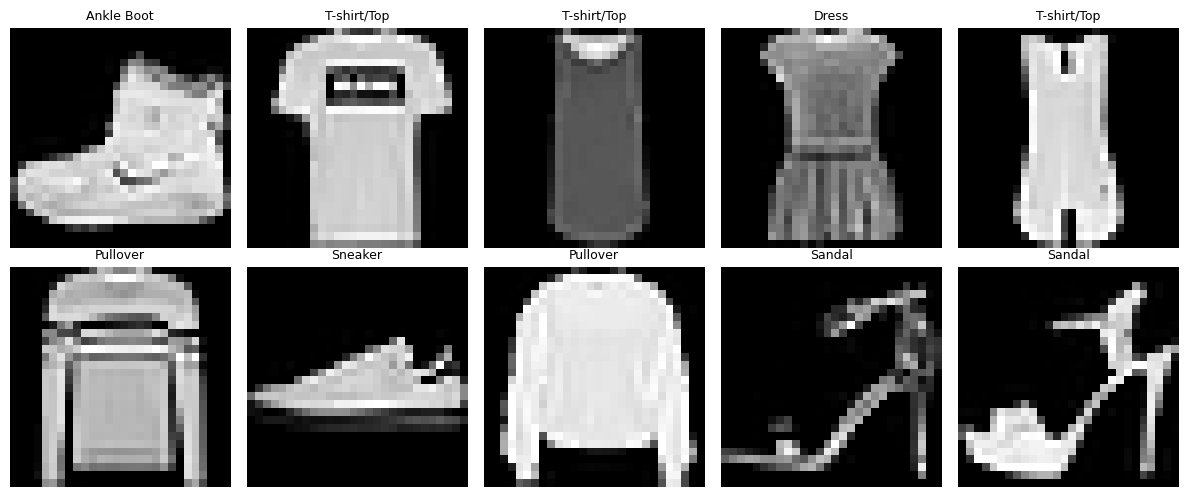

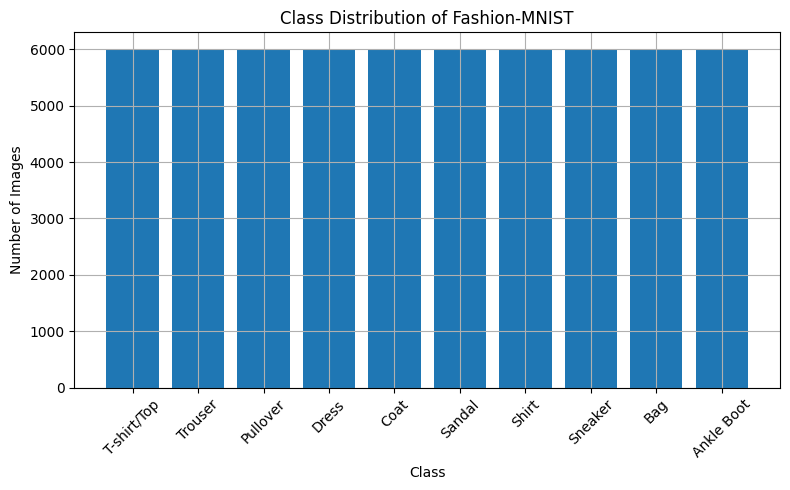

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist

class_names = [
    "T-shirt/Top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle Boot"
]

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("Training Images Shape :", x_train.shape)
print("Training Labels Shape :", y_train.shape)
print("Testing Images Shape  :", x_test.shape)
print("Testing Labels Shape  :", y_test.shape)

print("\nNumber of Training Images :", len(x_train))
print("Number of Testing Images  :", len(x_test))
print("Number of Classes         :", len(class_names))

plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(class_names[y_train[i]], fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.savefig(
    "sample_images.png",
    format="png",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

classes, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(8, 5))
plt.bar(classes, counts)
plt.xticks(classes, class_names, rotation=45)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution of Fashion-MNIST")
plt.tight_layout()
plt.grid(True)

plt.savefig(
    "class_distribution.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

# Task 2: Data Preprocessing

In [ ]:
from tensorflow.keras.utils import to_categorical

print("Shapes Before Preprocessing")
print("x_train :", x_train.shape)
print("x_test  :", x_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

x_train = x_train.reshape(x_train.shape[0], 784).astype("float32")
x_test = x_test.reshape(x_test.shape[0], 784).astype("float32")

x_train = x_train / 255.0
x_test = x_test / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("\nShapes After Preprocessing")
print("x_train :", x_train.shape)
print("x_test  :", x_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

Shapes Before Preprocessing
x_train : (60000, 28, 28)
x_test  : (10000, 28, 28)
y_train : (60000,)
y_test  : (10000,)

Shapes After Preprocessing
x_train : (60000, 784)
x_test  : (10000, 784)
y_train : (60000, 10)
y_test  : (10000, 10)


# Task 3: Model Construction

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

model = Sequential([
    Input(shape=(784,)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

model.summary()

I0000 00:00:1784714552.371773     755 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784714552.373457     755 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

# Task 4: Model Training

In [ ]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

train_history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(x_test, y_test),
    verbose=1
)

Epoch 1/20
  69/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5023 - loss: 1.4945

I0000 00:00:1784714555.814525     820 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8223 - loss: 0.4950 - val_accuracy: 0.8294 - val_loss: 0.4634
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8650 - loss: 0.3683 - val_accuracy: 0.8569 - val_loss: 0.3922
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8778 - loss: 0.3318 - val_accuracy: 0.8576 - val_loss: 0.3787
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8846 - loss: 0.3103 - val_accuracy: 0.8726 - val_loss: 0.3591
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8903 - loss: 0.2940 - val_accuracy: 0.8717 - val_loss: 0.3523
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8953 - loss: 0.2784 - val_accuracy: 0.8746 - val_loss: 0.3543
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8997 - loss: 0.2655 - val_accuracy: 0.8732 - val_loss: 0.3511
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9041 - loss: 0.2540 - val_accurac

# Task 5: Model Evaluation

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Accuracy : 0.891
Precision: 0.8909709795808197
Recall   : 0.891
F1-score : 0.8906847942242155


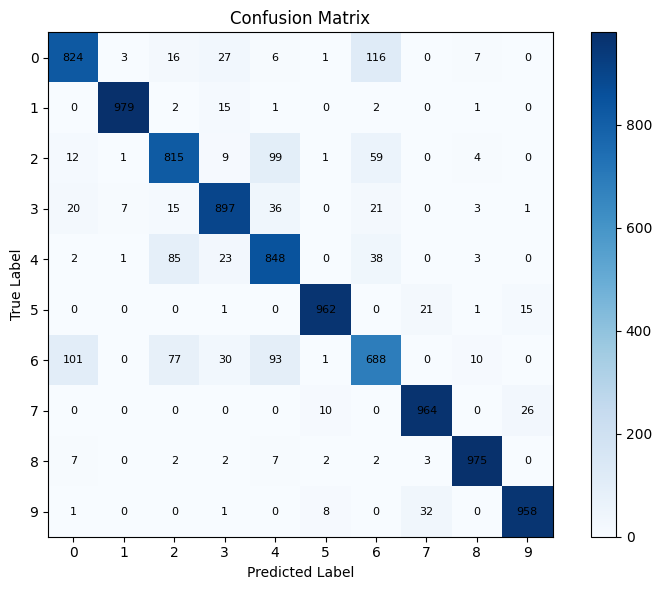


Classification Report

              precision    recall  f1-score   support

           0       0.85      0.82      0.84      1000
           1       0.99      0.98      0.98      1000
           2       0.81      0.81      0.81      1000
           3       0.89      0.90      0.89      1000
           4       0.78      0.85      0.81      1000
           5       0.98      0.96      0.97      1000
           6       0.74      0.69      0.71      1000
           7       0.95      0.96      0.95      1000
           8       0.97      0.97      0.97      1000
           9       0.96      0.96      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

y_pred = model.predict(x_test)

y_pred_classes = y_pred.argmax(axis=1)
y_true = y_test.argmax(axis=1)

accuracy = accuracy_score(y_true, y_pred_classes)
precision = precision_score(y_true, y_pred_classes, average="weighted")
recall = recall_score(y_true, y_pred_classes, average="weighted")
f1 = f1_score(y_true, y_pred_classes, average="weighted")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

plt.xticks(range(10))
plt.yticks(range(10))

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.savefig(
    "confusion_matrix.png",
    format="png",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

print("\nClassification Report\n")
print(classification_report(y_true, y_pred_classes))

# Hyperparameter Optimization

In [ ]:
import time
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV


def build_model(hidden_layers=2,
                hidden_neurons=128,
                learning_rate=0.001,
                optimizer="adam",
                activation="relu",
                dropout_rate=0.0):

    model = Sequential()

    model.add(Input(shape=(784,)))

    for _ in range(hidden_layers):
        model.add(Dense(hidden_neurons, activation=activation))

        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    model.add(Dense(10, activation="softmax"))

    if optimizer == "adam":
        opt = Adam(learning_rate=learning_rate)
    elif optimizer == "sgd":
        opt = SGD(learning_rate=learning_rate)
    else:
        opt = RMSprop(learning_rate=learning_rate)

    model.compile(
        optimizer=opt,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


baseline_model = build_model()

start = time.time()

baseline_history = baseline_model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(x_test, y_test),
    verbose=1
)

baseline_training_time = time.time() - start

baseline_accuracy = baseline_model.evaluate(
    x_test,
    y_test,
    verbose=0
)[1]


classifier = KerasClassifier(
    model=build_model,
    verbose=0
)

param_dist = {
    "model__hidden_layers": [1, 2, 3],
    "model__hidden_neurons": [32, 64, 128, 256],
    "model__learning_rate": [0.1, 0.01, 0.001],
    "model__optimizer": ["adam", "sgd", "rmsprop"],
    "model__activation": ["relu", "tanh", "sigmoid"],
    "model__dropout_rate": [0.0, 0.2, 0.5],
    "batch_size": [16, 32, 64, 128],
    "epochs": [10, 20, 30]
}

random_search = RandomizedSearchCV(
    estimator=classifier,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=1
)

random_search.fit(x_train, y_train)

best_params = random_search.best_params_

print("\nBest Hyperparameters\n")

for key, value in best_params.items():
    print(f"{key:25} : {value}")

print("\nBest Cross Validation Accuracy :", random_search.best_score_)


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

optimized_model = build_model(
    hidden_layers=best_params["model__hidden_layers"],
    hidden_neurons=best_params["model__hidden_neurons"],
    learning_rate=best_params["model__learning_rate"],
    optimizer=best_params["model__optimizer"],
    activation=best_params["model__activation"],
    dropout_rate=best_params["model__dropout_rate"]
)

start = time.time()

optimized_history = optimized_model.fit(
    x_train,
    y_train,
    epochs=best_params["epochs"],
    batch_size=best_params["batch_size"],
    validation_data=(x_test, y_test),
    verbose=1
)

optimized_training_time = time.time() - start

y_pred = optimized_model.predict(x_test)

y_pred_classes = y_pred.argmax(axis=1)
y_true = y_test.argmax(axis=1)

optimized_accuracy = accuracy_score(y_true, y_pred_classes)
optimized_precision = precision_score(
    y_true,
    y_pred_classes,
    average="weighted"
)

optimized_recall = recall_score(
    y_true,
    y_pred_classes,
    average="weighted"
)

optimized_f1 = f1_score(
    y_true,
    y_pred_classes,
    average="weighted"
)

baseline_pred = baseline_model.predict(x_test)

baseline_pred_classes = baseline_pred.argmax(axis=1)

baseline_precision = precision_score(
    y_true,
    baseline_pred_classes,
    average="weighted"
)

baseline_recall = recall_score(
    y_true,
    baseline_pred_classes,
    average="weighted"
)

baseline_f1 = f1_score(
    y_true,
    baseline_pred_classes,
    average="weighted"
)

print("\nClassification Report\n")
print(classification_report(y_true, y_pred_classes))

cm = confusion_matrix(y_true, y_pred_classes)

print("\nBest Hyperparameters")
print("-"*40)
print(f"Hidden Layers       : {best_params['model__hidden_layers']}")
print(f"Hidden Neurons      : {best_params['model__hidden_neurons']}")
print(f"Learning Rate       : {best_params['model__learning_rate']}")
print(f"Batch Size          : {best_params['batch_size']}")
print(f"Optimizer           : {best_params['model__optimizer']}")
print(f"Activation Function : {best_params['model__activation']}")
print(f"Epochs              : {best_params['epochs']}")
print(f"Dropout Rate        : {best_params['model__dropout_rate']}")
print(f"Cross Validation Accuracy : {random_search.best_score_:.4f}")
print(f"Testing Accuracy          : {optimized_accuracy:.4f}")

results = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "Training Time (s)"
    ],
    "Baseline":[
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1,
        baseline_training_time
    ],
    "Optimized":[
        optimized_accuracy,
        optimized_precision,
        optimized_recall,
        optimized_f1,
        optimized_training_time
    ]
})

print("\nPerformance Comparison\n")
print(results)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8251 - loss: 0.4897 - val_accuracy: 0.8463 - val_loss: 0.4209
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8674 - loss: 0.3628 - val_accuracy: 0.8562 - val_loss: 0.3887
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8792 - loss: 0.3278 - val_accuracy: 0.8660 - val_loss: 0.3711
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8879 - loss: 0.3037 - val_accuracy: 0.8726 - val_loss: 0.3599
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8932 - loss: 0.2878 - val_accuracy: 0.8767 - val_loss: 0.3338
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8972 - loss: 0.2735 - val_accuracy: 0.8695 - val_loss: 0.3705
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9010 - loss: 0.2596 - val_accuracy: 0.8855 - val_loss: 0.3345
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9060 - loss: 0.2491 - 

/usr/local/lib/python3.12/dist-packages/numpy/ma/core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,



Best Hyperparameters

model__optimizer          : rmsprop
model__learning_rate      : 0.001
model__hidden_neurons     : 128
model__hidden_layers      : 3
model__dropout_rate       : 0.2
model__activation         : tanh
epochs                    : 30
batch_size                : 32

Best Cross Validation Accuracy : 0.8870166666666666
Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7965 - loss: 0.5637 - val_accuracy: 0.8351 - val_loss: 0.4575
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8409 - loss: 0.4418 - val_accuracy: 0.8423 - val_loss: 0.4371
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8539 - loss: 0.4068 - val_accuracy: 0.8624 - val_loss: 0.3919
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8602 - loss: 0.3871 - val_accuracy: 0.8549 - val_loss: 0.4020
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8658 - loss: 0.3688 - val_accuracy: 0.8683 - val_loss: 0.3844
Epoch 6/30
187

# Complete Plots

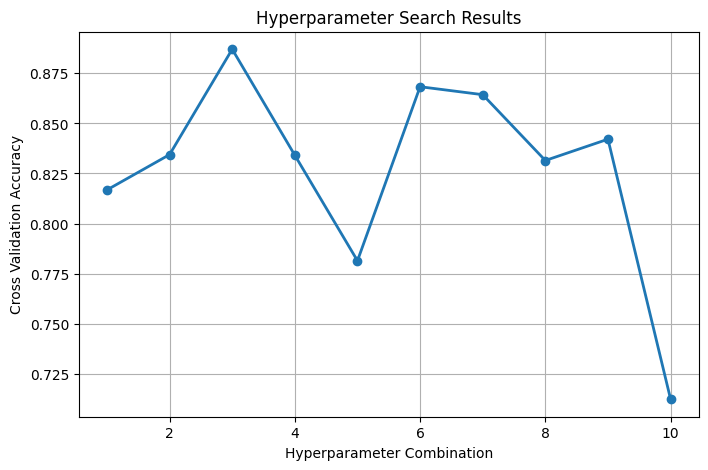

In [ ]:
cv_scores = random_search.cv_results_["mean_test_score"]

plt.figure(figsize=(8,5))
plt.plot(
    range(1, len(cv_scores)+1),
    cv_scores,
    marker="o",
    linewidth=2
)

plt.xlabel("Hyperparameter Combination")
plt.ylabel("Cross Validation Accuracy")
plt.title("Hyperparameter Search Results")
plt.grid(True)
plt.savefig(
    "hyperparameter_search.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

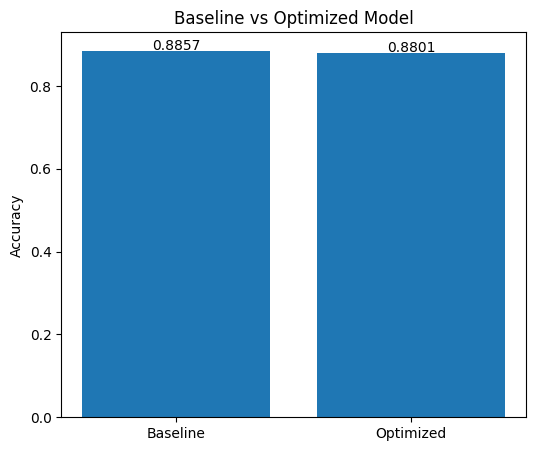

In [ ]:
plt.figure(figsize=(6,5))

plt.bar(
    ["Baseline","Optimized"],
    [baseline_accuracy, optimized_accuracy]
)

plt.ylabel("Accuracy")
plt.title("Baseline vs Optimized Model")

for i, value in enumerate([baseline_accuracy, optimized_accuracy]):
    plt.text(
        i,
        value + 0.002,
        f"{value:.4f}",
        ha="center",
        fontsize=10
    )
plt.savefig(
    "accuracy_comparison.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import RMSprop

best_model = Sequential()

best_model.add(Input(shape=(784,)))

best_model.add(Dense(128, activation="tanh"))
best_model.add(Dropout(0.2))

best_model.add(Dense(128, activation="tanh"))
best_model.add(Dropout(0.2))

best_model.add(Dense(128, activation="tanh"))
best_model.add(Dropout(0.2))

best_model.add(Dense(10, activation="softmax"))

best_model.compile(
    optimizer=RMSprop(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

best_history = best_model.fit(
    x_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_data=(x_test, y_test),
    verbose=1
)

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7965 - loss: 0.5649 - val_accuracy: 0.8083 - val_loss: 0.5128
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8409 - loss: 0.4416 - val_accuracy: 0.8541 - val_loss: 0.4163
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8536 - loss: 0.4092 - val_accuracy: 0.8605 - val_loss: 0.4008
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8608 - loss: 0.3882 - val_accuracy: 0.8614 - val_loss: 0.3863
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8670 - loss: 0.3736 - val_accuracy: 0.8612 - val_loss: 0.3929
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8702 - loss: 0.3631 - val_accuracy: 0.8676 - val_loss: 0.3735
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8738 - loss: 0.3554 - val_accuracy: 0.8663 - val_loss: 0.3901
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8758 - loss: 0.3447 - 

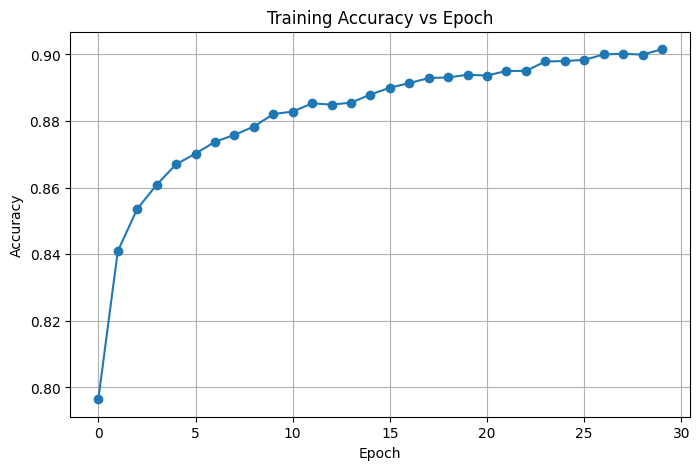

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(best_history.history["accuracy"], marker="o")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy vs Epoch")
plt.grid(True)
plt.savefig(
    "training_accuracy.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

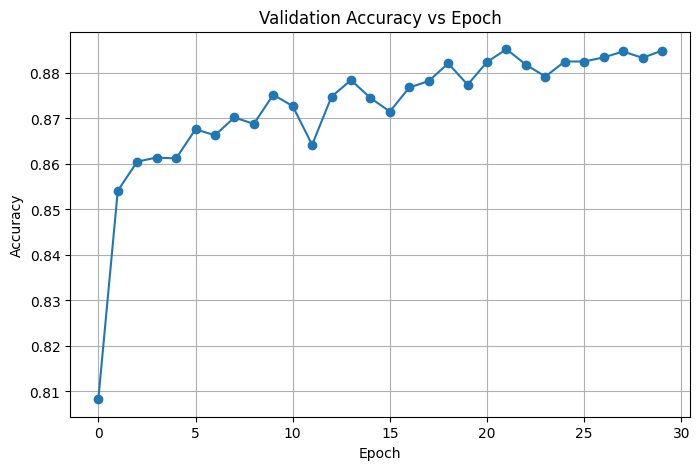

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(best_history.history["val_accuracy"], marker="o")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy vs Epoch")
plt.grid(True)
plt.savefig(
    "validation_accuracy.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

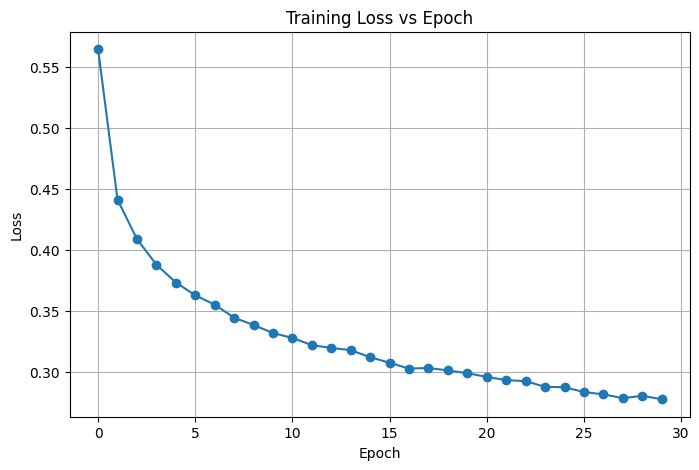

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(best_history.history["loss"], marker="o")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Epoch")
plt.grid(True)
plt.savefig(
    "training_loss.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

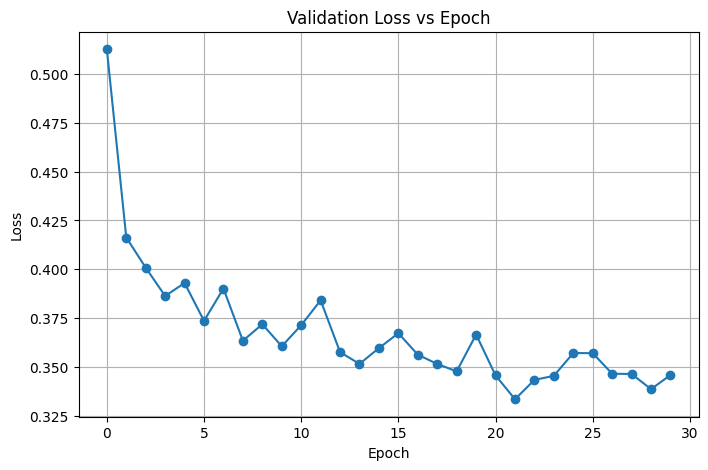

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(best_history.history["val_loss"], marker="o")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation Loss vs Epoch")
plt.grid(True)
plt.savefig(
    "validation_loss.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

In [1]:
# ============================================
# XOR Problem using Multi-Layer Perceptron
# ============================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# XOR input and output
X_xor = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=np.float32)

y_xor = np.array([
    [0],
    [1],
    [1],
    [0]
], dtype=np.float32)

print("XOR Inputs:")
print(X_xor)

print("\nXOR Outputs:")
print(y_xor.ravel())

XOR Inputs:
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]

XOR Outputs:
[0. 1. 1. 0.]


In [2]:
# Build MLP for XOR
xor_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(4, activation="tanh"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

xor_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.05),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

xor_model.summary()

# Train the XOR MLP
xor_history = xor_model.fit(
    X_xor,
    y_xor,
    epochs=500,
    verbose=0
)

print("XOR MLP training completed.")

# Predictions
xor_probabilities = xor_model.predict(X_xor, verbose=0)
xor_predictions = (xor_probabilities >= 0.5).astype(int)

print("\nXOR Predictions:")
for i in range(len(X_xor)):
    print(
        f"Input: {X_xor[i]} | "
        f"Actual: {int(y_xor[i][0])} | "
        f"Predicted: {xor_predictions[i][0]} | "
        f"Probability: {xor_probabilities[i][0]:.4f}"
    )

xor_accuracy = np.mean(xor_predictions.ravel() == y_xor.ravel())

print(f"\nXOR Accuracy: {xor_accuracy * 100:.2f}%")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

XOR MLP training completed.

XOR Predictions:
Input: [0. 0.] | Actual: 0 | Predicted: 0 | Probability: 0.0012
Input: [0. 1.] | Actual: 1 | Predicted: 1 | Probability: 0.9999
Input: [1. 0.] | Actual: 1 | Predicted: 1 | Probability: 0.9974
Input: [1. 1.] | Actual: 0 | Predicted: 0 | Probability: 0.0027

XOR Accuracy: 100.00%


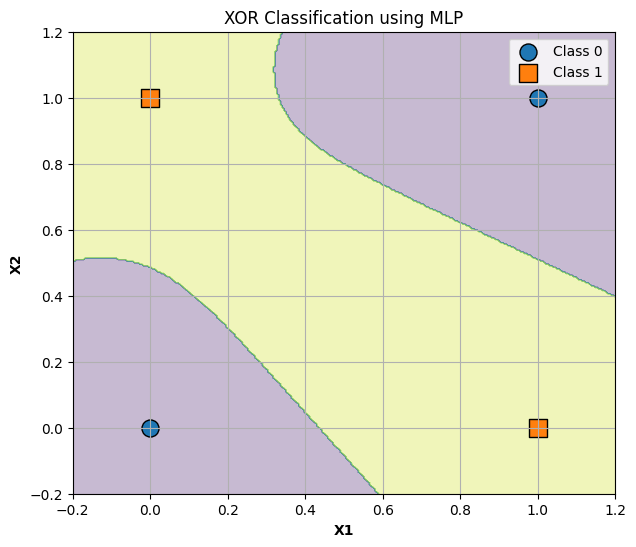

In [4]:
# ============================================
# XOR Decision Boundary Visualization
# ============================================

xx, yy = np.meshgrid(
    np.linspace(-0.2, 1.2, 300),
    np.linspace(-0.2, 1.2, 300)
)

grid_points = np.c_[xx.ravel(), yy.ravel()]

Z = xor_model.predict(grid_points, verbose=0)
Z = (Z >= 0.5).astype(int)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(7, 6))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.3
)

for class_value, marker in [(0, "o"), (1, "s")]:
    mask = y_xor.ravel() == class_value

    plt.scatter(
        X_xor[mask, 0],
        X_xor[mask, 1],
        marker=marker,
        s=150,
        edgecolors="black",
        label=f"Class {class_value}"
    )

plt.xlabel("X1", fontweight="bold")
plt.ylabel("X2", fontweight="bold")
plt.title("XOR Classification using MLP")
plt.legend()
plt.grid(True)

plt.savefig(
    "xor_decision_boundary.pdf",
    format="pdf",
    dpi=600,
    bbox_inches="tight"
)

plt.show()